In [5]:
import json
import re
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

CSV_BID_FILE_SIZE = 6678514674        # bytes
CSV_PERSON_FILE_SIZE = 880941057      # bytes
JSON_BID_FILE_SIZE = 15878100724      # bytes
JSON_PERSON_FILE_SIZE = 1300941057    # bytes

def shorten_query(q):
    q = re.sub(r"\s+INTO\s+\w+", "", q, flags=re.IGNORECASE)
    q = re.sub(r'VARSIZED\("([^"]+)"\)', r'"\1"', q)
    q = re.sub(r'INT32\((\d+)\)', r'\1', q)
    q = re.sub(r'FLOAT64\(([\d.]+)\)', r'\1', q)
    return re.sub(r'\s+', ' ', q).strip()

def get_file_size(query, suite_name):
    is_json = "json" in suite_name.lower()
    if "from bid" in query.lower():
        return JSON_BID_FILE_SIZE if is_json else CSV_BID_FILE_SIZE
    return JSON_PERSON_FILE_SIZE if is_json else CSV_PERSON_FILE_SIZE

def load_suite(filepath, suite_name):
    with open(filepath) as f:
        data = json.load(f)
    rows = []
    for r in data:
        if r.get("status") != "Stopped" or not r.get("started") or not r.get("stopped"):
            continue
        started = datetime.strptime(r["started"], "%Y-%m-%d %H:%M:%S.%f")
        stopped = datetime.strptime(r["stopped"], "%Y-%m-%d %H:%M:%S.%f")
        exec_time = (stopped - started).total_seconds()
        query = shorten_query(r["query"].strip())
        file_size = get_file_size(query, suite_name)
        rows.append({
            "suite": suite_name,
            "query": query,
            "threads": r["threads_number"],
            "exec_time_s": exec_time,
            "throughput_MBs": file_size / exec_time / (1024 * 1024),
        })
    return rows

rows = []
rows += load_suite("results/baseline_results_1776772875.json", "CSV baseline")
rows += load_suite("results/optimized_results_1776776907.json", "CSV optimized")
rows += load_suite("results/baseline-json_results_1776780239.json", "JSON baseline")
rows += load_suite("results/optimized-json_results_1776785610.json", "JSON optimized")
df = pd.DataFrame(rows)
print(f"Records: {len(df)}")
print(f"Suites: {sorted(df['suite'].unique())}")
print(f"Threads: {sorted(df['threads'].unique())}")
print(f"Queries: {sorted(df['query'].unique())}")
df

Records: 288
Suites: ['CSV baseline', 'CSV optimized', 'JSON baseline', 'JSON optimized']
Threads: [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64)]
Queries: ['SELECT auctionId FROM bid WHERE bidder == 1001', 'SELECT auctionId FROM bid WHERE bidder == 1001 AND price == 220', 'SELECT auctionId FROM bid WHERE bidder == 1001 OR bidder == 1002', 'SELECT auctionId FROM bid WHERE price == 220', 'SELECT auctionId FROM bid WHERE timestamp == UINT64(1746560847870)', 'SELECT id FROM person WHERE city == "redmond"']


,suite,query,threads,exec_time_s,throughput_MBs
0,CSV baseline,SELECT auctionId FROM bid WHERE bidder == 1001,2,182.987,34.806450
1,CSV baseline,SELECT auctionId FROM bid WHERE bidder == 1001,2,183.056,34.793331
2,CSV baseline,SELECT auctionId FROM bid WHERE price == 220,2,182.858,34.831005
3,CSV baseline,SELECT auctionId FROM bid WHERE price == 220,2,182.490,34.901243
4,CSV baseline,SELECT auctionId FROM bid WHERE timestamp == U...,2,182.724,34.856548
...,...,...,...,...,...
283,JSON optimized,"SELECT id FROM person WHERE city == ""redmond""",64,0.739,1678.855309
284,JSON optimized,SELECT auctionId FROM bid WHERE bidder == 1001...,64,15.836,956.209703
285,JSON optimized,SELECT auctionId FROM bid WHERE bidder == 1001...,64,15.345,986.805921
286,JSON optimized,SELECT auctionId FROM bid WHERE bidder == 1001...,64,15.573,972.358367


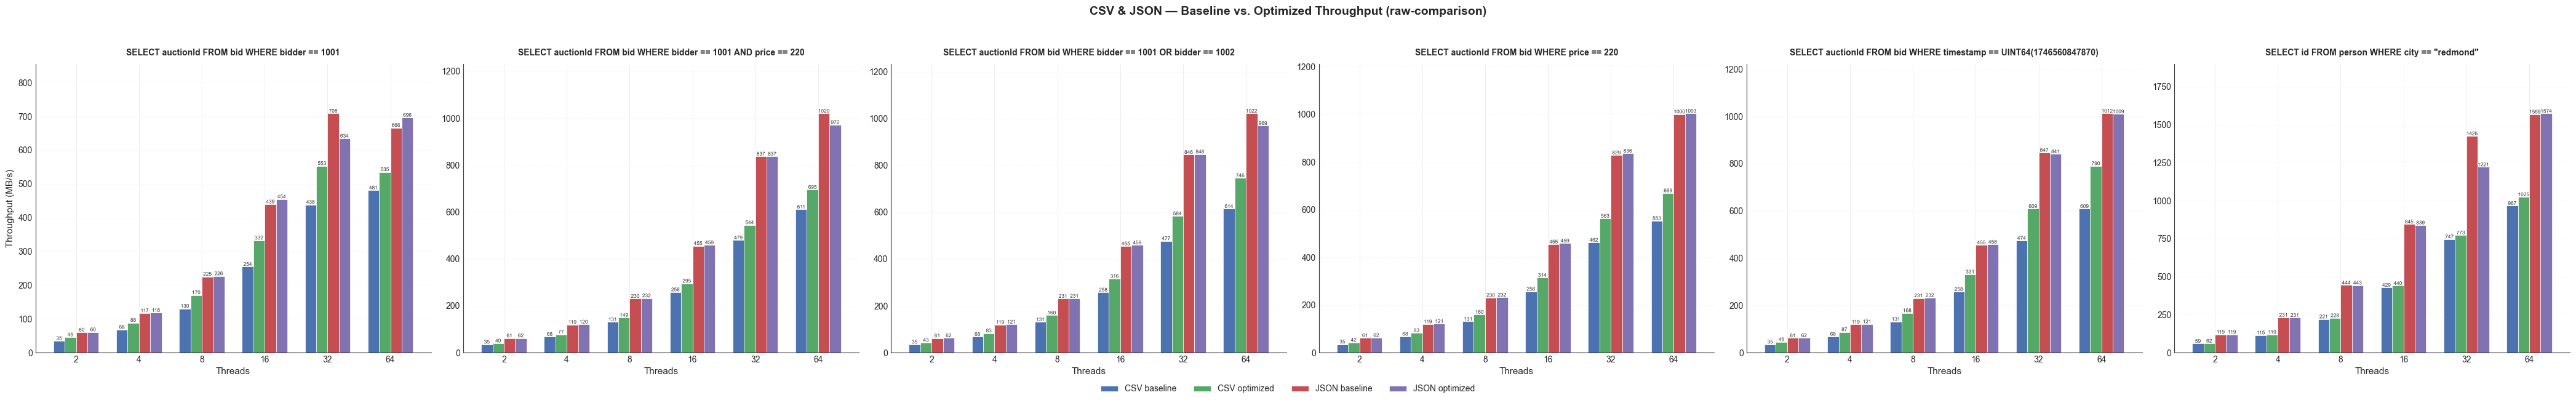

In [6]:
# Grouped bar chart: 4 suites per thread count, one subplot per query
import numpy as np
import matplotlib.patheffects as pe

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
})

queries = sorted(df["query"].unique())
suites = ["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]
suite_colors = {
    "CSV baseline":  "#4C72B0",
    "CSV optimized": "#55A868",
    "JSON baseline": "#C44E52",
    "JSON optimized": "#8172B2",
}
thread_counts = sorted(df["threads"].unique())
n_suites = len(suites)
bar_width = 0.18

fig, axes = plt.subplots(1, len(queries), figsize=(7 * len(queries), 6),
                          sharey=False, squeeze=False)

x = np.arange(len(thread_counts))

for i, q in enumerate(queries):
    ax = axes[0, i]
    for j, suite in enumerate(suites):
        s_data = df[(df["query"] == q) & (df["suite"] == suite)]
        vals = s_data.groupby("threads")["throughput_MBs"].median().reindex(thread_counts)
        offset = (j - (n_suites - 1) / 2) * bar_width
        bars = ax.bar(x + offset, vals.values, bar_width, label=suite,
                       color=suite_colors[suite], edgecolor="white", linewidth=0.5,
                       zorder=3)
        for bar in bars:
            h = bar.get_height()
            if h is not None and not np.isnan(h):
                txt = ax.text(bar.get_x() + bar.get_width() / 2, h + 1,
                              f"{h:.0f}", ha="center", va="bottom", fontsize=6,
                              color="#333333", fontweight="medium")
                txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

    ax.set_xlabel("Threads", fontsize=11, fontweight="medium")
    ax.set_ylabel("Throughput (MB/s)" if i == 0 else "", fontsize=11, fontweight="medium")
    ax.set_title(q, fontsize=10, fontweight="bold", pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(thread_counts)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.grid(True, alpha=0.25, axis="y", linestyle="--", zorder=0)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Single shared legend at the bottom
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=n_suites, fontsize=10,
           framealpha=0.9, edgecolor="#cccccc", bbox_to_anchor=(0.5, -0.04))

fig.suptitle("CSV & JSON — Baseline vs. Optimized Throughput (raw-comparison)",
             fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

In [7]:
# Summary table: throughput (MB/s) all 4 suites
pivot = df.pivot_table(index=["query", "threads"], columns="suite", values="throughput_MBs", aggfunc="median")
pivot = pivot[["CSV baseline", "CSV optimized", "JSON baseline", "JSON optimized"]]
pivot["CSV speedup"] = pivot["CSV optimized"] / pivot["CSV baseline"]
pivot["JSON speedup"] = pivot["JSON optimized"] / pivot["JSON baseline"]
pivot.round(2)

suite                                                       CSV baseline  \
query                                              threads                 
SELECT auctionId FROM bid WHERE bidder == 1001     2               34.80   
                                                   4               67.69   
                                                   8              130.26   
                                                   16             254.35   
                                                   32             438.26   
                                                   64             480.85   
SELECT auctionId FROM bid WHERE bidder == 1001 ... 2               34.83   
                                                   4               67.72   
                                                   8              130.71   
                                                   16             257.91   
                                                   32             479.24   
                                                   64             610.80   
SELECT auctionId FROM bid WHERE bidder == 1001 ... 2               34.84   
                                                   4               67.68   
                                                   8              130.64   
                                                   16             257.77   
                                                   32             477.16   
                                                   64             614.46   
SELECT auctionId FROM bid WHERE price == 220       2               34.87   
                                                   4               67.66   
                                                   8              130.52   
                                                   16             256.41   
                                                   32             462.40   
                                                   64             553.43   
SELECT auctionId FROM bid WHERE timestamp == UI... 2               34.85   
                                                   4               67.68   
                                                   8              130.73   
                                                   16             257.53   
                                                   32             473.83   
                                                   64             608.77   
SELECT id FROM person WHERE city == "redmond"      2               59.48   
                                                   4              115.05   
                                                   8              220.51   
                                                   16             428.86   
                                                   32             746.78   
                                                   64             966.81   

suite                                                       CSV optimized  \
query                                              threads                  
SELECT auctionId FROM bid WHERE bidder == 1001     2                45.42   
                                                   4                88.36   
                                                   8               170.11   
                                                   16              332.43   
                                                   32              552.95   
                                                   64              534.98   
SELECT auctionId FROM bid WHERE bidder == 1001 ... 2                39.81   
                                                   4                77.49   
                                                   8               149.35   
                                                   16              294.79   
                                                   32              544.22   
                                                   64              694.90   
SELECT auctionId FROM bid WHERE b